In [ ]:
import pandas as pd
import json
import ir_datasets
from src.data import DATA_DIR_PROCESSED
import os
from topic_gen.evaluate import QrelsEvaluator, CohenKappa, MeanAverageError, AreaUnderReceiver,  binarize_qrels
import ir_measures
from pathlib import Path
from typing import List
from statsmodels.stats import inter_rater as irr
import numpy as np
import krippendorff as kd
import seaborn as sns
import matplotlib.pyplot as plt

from topic_gen import logger
logger.setLevel("DEBUG")

In [2]:
# Load generated qrels from path
BASE_DIR = DATA_DIR_PROCESSED / "qrels"

predictions = []
names = []
metadata_records = []
for result in os.listdir(BASE_DIR):
    names.append(result)

    # metadata
    with open(os.path.join(BASE_DIR, result, "metadata.json")) as f:
        metadata = json.load(f)
    metadata_records.append(metadata)

    # predictions
    qrels = binarize_qrels(ir_measures.read_trec_qrels(
        os.path.join(BASE_DIR, result, "qrels.csv.gz")))
    predictions.append(qrels)

In [3]:
# Evaluate qrels
res = QrelsEvaluator.experiment(
    predictions=predictions,
    references=binarize_qrels(ir_datasets.load(
        "disks45/nocr/trec-robust-2004").qrels_iter()),
    measures=[CohenKappa(), MeanAverageError(), AreaUnderReceiver()],
    bootstrap=20,
    names=names)

[topic_gen] [INFO] (evaluate.py:249) Qrels in reference but not in predictions: 12 / 2939
[topic_gen] [INFO] (evaluate.py:249) Qrels in reference but not in predictions: 8 / 2943
[topic_gen] [INFO] (evaluate.py:249) Qrels in reference but not in predictions: 0 / 2951
[topic_gen] [INFO] (evaluate.py:249) Qrels in reference but not in predictions: 11 / 2940
[topic_gen] [INFO] (evaluate.py:249) Qrels in reference but not in predictions: 4 / 2947
[topic_gen] [INFO] (evaluate.py:249) Qrels in reference but not in predictions: 10 / 2941
[topic_gen] [INFO] (evaluate.py:249) Qrels in reference but not in predictions: 0 / 2951
[topic_gen] [INFO] (evaluate.py:249) Qrels in reference but not in predictions: 0 / 2951
[topic_gen] [INFO] (evaluate.py:249) Qrels in reference but not in predictions: 2 / 2949
[topic_gen] [INFO] (evaluate.py:249) Qrels in reference but not in predictions: 15 / 2936
[topic_gen] [INFO] (evaluate.py:249) Qrels in reference but not in predictions: 9 / 2942
[topic_gen] [INFO

In [4]:
# metadata table
metadata = pd.DataFrame(metadata_records)
metadata = metadata.join(pd.json_normalize(
    metadata["topics"]).add_prefix("topics_"))
metadata.drop(columns=["topics"], inplace=True)
metadata["topics_prompt"] = metadata["topics_prompt"].apply(
    lambda p: str(Path(p).stem) if pd.notnull(p) else "human")
metadata["prompt"] = metadata["prompt"].apply(lambda p: str(Path(p).stem))
metadata["model"] = metadata["model"].str.replace("-MT1000", "")
metadata["model"] = metadata["model"].str.replace("-MT100", "")

In [5]:
def format_score(row):
    return f"{row['value']:.2f} ± {row['ci']:.2f}"


table = pd.DataFrame(res)
table["score"] = table.apply(format_score, axis=1)
table = table.pivot(index="name", columns="measure",
                    values="score").reset_index()

In [6]:
table = table.merge(metadata, left_on="name", right_on="date")

In [7]:
def agreement(dfs: List[pd.DataFrame]):
    df = dfs[0]
    rating_cols = ["relevance"]
    for idx, d in enumerate(dfs[1:]):
        df = df.merge(d, on=["query_id", "doc_id"],
                      suffixes=("", f"_r{idx+1}"))

        rating_cols.append(f"relevance_r{idx+1}")
    agg = irr.aggregate_raters(df[rating_cols])
    # fleiss kappa
    fleiss = irr.fleiss_kappa(agg[0], method='fleiss')

    arrT = np.array(df[rating_cols]).transpose()
    krippendorf = kd.alpha(arrT, level_of_measurement='nominal')

    return fleiss, krippendorf

## Clarity
RQ: How well do different annotators agree on the relevance label using the generated topics?

### Inter-Rater Reliability Graded+Error (Label: 0,1,2,999)
- Fleiss Kappa shows a moderate (>0.4) to just barely substantial (>0.6) agreement across all three LLM annotators and topic prompts.


In [60]:
results = []
for i, df in table.groupby(by=["topics_model", "topics_prompt", "topics_nqueries", "topics_ndocsneg", "topics_ndocspos"]):
    row = df.iloc[0]
    name = row["topics_model"] + "_" + row["topics_prompt"] + \
        "-" + str(int(row["topics_nqueries"])) + \
        "-" + str(int(row["topics_ndocsneg"])) + \
        "-" + str(int(row["topics_ndocspos"]))
    qrels_dfs = []
    for run in df["name"]:
        qrel = pd.DataFrame(ir_measures.read_trec_qrels(
            os.path.join(BASE_DIR, run, "qrels.csv.gz")))
        qrels_dfs.append(qrel)

    fleiss, krippendorf = agreement(qrels_dfs)

    results.append({
        "name": name,
        "krippendorf": krippendorf,
        "fleiss": fleiss
    })
df = pd.DataFrame(results)
df

/tmp/ipykernel_2680808/1785998150.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, df in table.groupby(by=["topics_model", "topics_prompt", "topics_nqueries", "topics_ndocsneg", "topics_ndocspos"]):


,name,krippendorf,fleiss
0,gpt-oss-120B_trec-1-3-1,0.532897,0.532844
1,gpt-oss-120B_trec-3-3-2,0.570828,0.570779
2,gpt-oss-120B_trec-5-3-3,0.554660,0.554610
3,gpt-oss-120B_trec-query-1-3-3,0.539196,0.539144
4,gpt-oss-120B_trec-query-3-3-3,0.530332,0.530279
5,gpt-oss-120B_trec-query-5-3-3,0.530443,0.530390
6,gpt-oss-120B_trec-contrastive-1-1-1,0.537047,0.536994
7,gpt-oss-120B_trec-contrastive-5-3-3,0.556976,0.556925
8,qwen3-14B-no-think_trec-1-3-1,0.583660,0.583613
9,qwen3-14B-no-think_trec-3-3-2,0.552129,0.552079


### Inter-Rater Reliability Binary+Error (Label: 0,1,999)

In [61]:
results = []
for i, df in table.groupby(by=["topics_model", "topics_prompt", "topics_nqueries", "topics_ndocsneg", "topics_ndocspos"]):
    row = df.iloc[0]
    name = row["topics_model"] + "_" + row["topics_prompt"] + \
        "-" + str(int(row["topics_nqueries"])) + \
        "-" + str(int(row["topics_ndocsneg"])) + \
        "-" + str(int(row["topics_ndocspos"]))
    qrels_dfs = []
    for run in df["name"]:
        qrel = pd.DataFrame(binarize_qrels(ir_measures.read_trec_qrels(
            os.path.join(BASE_DIR, run, "qrels.csv.gz"))))
        qrels_dfs.append(qrel)

    fleiss, krippendorf = agreement(qrels_dfs)

    results.append({
        "name": name,
        "krippendorf": krippendorf,
        "fleiss": fleiss
    })
df = pd.DataFrame(results)
df

/tmp/ipykernel_2680808/3189129994.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, df in table.groupby(by=["topics_model", "topics_prompt", "topics_nqueries", "topics_ndocsneg", "topics_ndocspos"]):


,name,krippendorf,fleiss
0,gpt-oss-120B_trec-1-3-1,0.653782,0.653742
1,gpt-oss-120B_trec-3-3-2,0.699037,0.699003
2,gpt-oss-120B_trec-5-3-3,0.681080,0.681044
3,gpt-oss-120B_trec-query-1-3-3,0.650904,0.650864
4,gpt-oss-120B_trec-query-3-3-3,0.627062,0.627020
5,gpt-oss-120B_trec-query-5-3-3,0.634530,0.634489
6,gpt-oss-120B_trec-contrastive-1-1-1,0.683354,0.683318
7,gpt-oss-120B_trec-contrastive-5-3-3,0.697405,0.697370
8,qwen3-14B-no-think_trec-1-3-1,0.714146,0.714114
9,qwen3-14B-no-think_trec-3-3-2,0.677201,0.677165


### Cross Matrix (binary)

/tmp/ipykernel_2680808/1323816011.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = table.groupby(by=["prompt", "topics_prompt", "topics_nqueries", "topics_ndocsneg", "topics_ndocspos"])


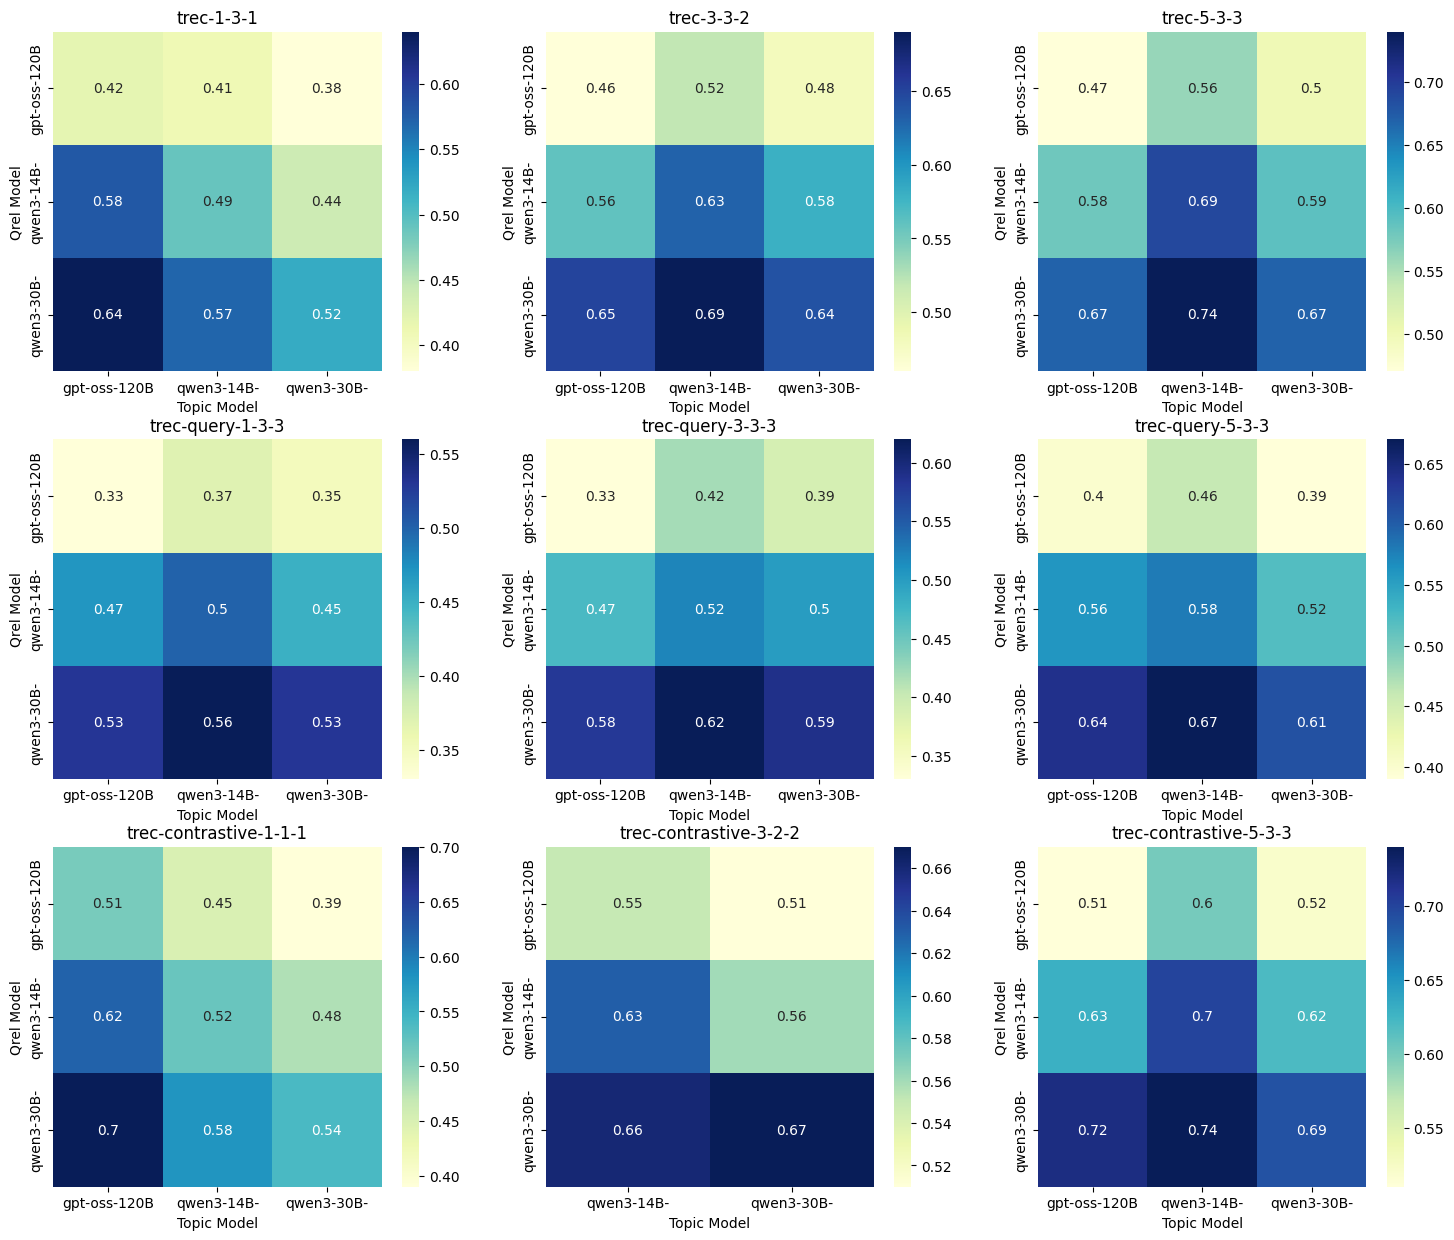

In [59]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes_flat = axes.flatten()

groups = table.groupby(by=["prompt", "topics_prompt",
                       "topics_nqueries", "topics_ndocsneg", "topics_ndocspos"])

for ax, (key, df) in zip(axes_flat, groups):
    df = df.copy()

    row = df.iloc[0]
    name = row["topics_prompt"] + \
        "-" + str(int(row["topics_nqueries"])) + \
        "-" + str(int(row["topics_ndocsneg"])) + \
        "-" + str(int(row["topics_ndocspos"]))

    df["CohenKappa"] = df["CohenKappa"].apply(
        lambda x: float(str(x).split(" ± ")[0]))
    df["model"] = df["model"].str.replace("no-think", "")
    df["topics_model"] = df["topics_model"].str.replace("no-think", "")
    df_pivot = df[["name", "CohenKappa", "model", "topics_model"]].pivot(
        index="model",
        columns="topics_model",
        values="CohenKappa"
    )

    sns.heatmap(df_pivot,
                annot=True,
                cmap='YlGnBu',
                ax=ax,
                # vmin=0.5,
                # vmax=0.8
                )
    ax.set_xlabel('Topic Model')
    ax.set_ylabel('Qrel Model')
    ax.set_title(name)

if len(groups) < len(axes_flat):
    for i in range(len(groups), len(axes_flat)):
        fig.delaxes(axes_flat[i])